In [46]:
from stock_data_analyser import StockDataAnalyser
sda= StockDataAnalyser(stock_symbol='AAPL')

In [47]:
sda.fetch_from_db_and_analyze()

In [48]:
df=sda.stock_data

In [49]:
df.head()

,index,Open,High,Low,Close,Volume,EMA,Bollinger_Upper,Bollinger_Lower,Close_Lag1,...,Close_Lag12,Close_Lag13,Close_Lag14,Close_Lag15,Close_Lag16,Close_Lag17,Close_Lag18,Close_Lag19,Trend,Stock_name
0,2025-03-04,237.705,240.0700,234.680,235.93,53798062,224.784136,239.290079,204.582921,235.74,...,214.10,218.27,220.73,223.75,221.53,223.85,217.90,222.13,NaN,AAPL
1,2025-03-03,241.790,244.0272,236.112,238.03,47183985,226.045647,241.519904,203.943096,235.93,...,215.24,214.10,218.27,220.73,223.75,221.53,223.85,217.90,NaN,AAPL
2,2025-02-28,236.950,242.0900,230.200,241.84,56833360,227.549871,244.396215,203.460785,238.03,...,212.69,215.24,214.10,218.27,220.73,223.75,221.53,223.85,NaN,AAPL
3,2025-02-27,239.410,242.4600,237.060,237.30,41153639,228.478455,245.923835,203.278165,241.84,...,214.00,212.69,215.24,214.10,218.27,220.73,223.75,221.53,NaN,AAPL
4,2025-02-26,244.330,244.9800,239.130,240.36,44433564,229.610030,247.930641,203.154359,237.30,...,213.49,214.00,212.69,215.24,214.10,218.27,220.73,223.75,NaN,AAPL


In [91]:
main_data=df[['Close']]
output=df[['High']]

In [93]:
# write code to ignore warnings

import warnings
warnings.filterwarnings('ignore')

for i in range(1, 25):
    main_data[f'Close_Lag{i}'] = main_data['Close'].shift(-i)

main_data.drop(main_data.tail(25).index, inplace=True)
main_data=main_data.drop(['Close'], axis=1)



In [94]:
main_data.corr()

,Close_Lag1,Close_Lag2,Close_Lag3,Close_Lag4,Close_Lag5,Close_Lag6,Close_Lag7,Close_Lag8,Close_Lag9,Close_Lag10,...,Close_Lag15,Close_Lag16,Close_Lag17,Close_Lag18,Close_Lag19,Close_Lag20,Close_Lag21,Close_Lag22,Close_Lag23,Close_Lag24
Close_Lag1,1.000000,0.996011,0.991818,0.987902,0.984216,0.980504,0.976676,0.972673,0.968611,0.964962,...,0.945770,0.941894,0.938096,0.934695,0.931434,0.928029,0.924490,0.920972,0.917465,0.913911
Close_Lag2,0.996011,1.000000,0.996007,0.991797,0.987854,0.984203,0.980497,0.976651,0.972599,0.968534,...,0.949639,0.945682,0.941776,0.937928,0.934496,0.931237,0.927861,0.924295,0.920726,0.917260
Close_Lag3,0.991818,0.996007,1.000000,0.996009,0.991769,0.987830,0.984177,0.980457,0.976574,0.972516,...,0.953203,0.949602,0.945620,0.941637,0.937764,0.934328,0.931118,0.927671,0.924053,0.920504
Close_Lag4,0.987902,0.991797,0.996009,1.000000,0.996000,0.991798,0.987857,0.984184,0.980437,0.976546,...,0.956987,0.953147,0.949524,0.945494,0.941486,0.937611,0.934201,0.930959,0.927474,0.923883
Close_Lag5,0.984216,0.987854,0.991769,0.996000,1.000000,0.996014,0.991800,0.987840,0.984155,0.980397,...,0.960508,0.956964,0.953107,0.949415,0.945368,0.941352,0.937518,0.934038,0.930760,0.927282
Close_Lag6,0.980504,0.984203,0.987830,0.991798,0.996014,1.000000,0.996000,0.991773,0.987793,0.984101,...,0.964501,0.960574,0.957010,0.953040,0.949334,0.945273,0.941329,0.937363,0.933832,0.930547
Close_Lag7,0.976676,0.980497,0.984177,0.987857,0.991800,0.996000,1.000000,0.995988,0.991734,0.987748,...,0.968169,0.964578,0.960627,0.956952,0.952965,0.949246,0.945257,0.941185,0.937163,0.933628
Close_Lag8,0.972673,0.976651,0.980457,0.984184,0.987840,0.991773,0.995988,1.000000,0.995963,0.991701,...,0.972201,0.968232,0.964620,0.960566,0.956874,0.952875,0.949222,0.945119,0.940993,0.936970
Close_Lag9,0.968611,0.972599,0.976574,0.980437,0.984155,0.987793,0.991734,0.995963,1.000000,0.995949,...,0.976248,0.972286,0.968302,0.964584,0.960520,0.956812,0.952881,0.949098,0.944953,0.940808
Close_Lag10,0.964962,0.968534,0.972516,0.976546,0.980397,0.984101,0.987748,0.991701,0.995949,1.000000,...,0.980134,0.976332,0.972354,0.968269,0.964540,0.960461,0.956817,0.952766,0.948943,0.944783


In [95]:

from sklearn.decomposition import PCA
pca=PCA(n_components=4)
temp=pca.fit_transform(main_data)


In [96]:
for i in range(0, temp.shape[1]):
    main_data[f'pca{i}'] = temp[:, i]


In [97]:
main_data.head()

,Close_Lag1,Close_Lag2,Close_Lag3,Close_Lag4,Close_Lag5,Close_Lag6,Close_Lag7,Close_Lag8,Close_Lag9,Close_Lag10,...,Close_Lag19,Close_Lag20,Close_Lag21,Close_Lag22,Close_Lag23,Close_Lag24,pca0,pca1,pca2,pca3
0,238.03,241.84,237.30,240.36,247.04,247.10,245.55,245.83,244.87,244.47,...,232.80,228.01,236.00,237.59,239.36,238.26,314.701945,-11.945388,2.813383,-21.058760
1,241.84,237.30,240.36,247.04,247.10,245.55,245.83,244.87,244.47,244.60,...,228.01,236.00,237.59,239.36,238.26,229.86,313.054147,-14.252480,7.018985,-16.869068
2,237.30,240.36,247.04,247.10,245.55,245.83,244.87,244.47,244.60,241.53,...,236.00,237.59,239.36,238.26,229.86,222.78,309.213873,-17.123614,7.719946,-9.221855
3,240.36,247.04,247.10,245.55,245.83,244.87,244.47,244.60,241.53,236.87,...,237.59,239.36,238.26,229.86,222.78,223.66,306.457792,-20.616803,9.664103,0.919346
4,247.04,247.10,245.55,245.83,244.87,244.47,244.60,241.53,236.87,232.62,...,239.36,238.26,229.86,222.78,223.66,223.83,303.095636,-22.721305,10.269098,9.918214


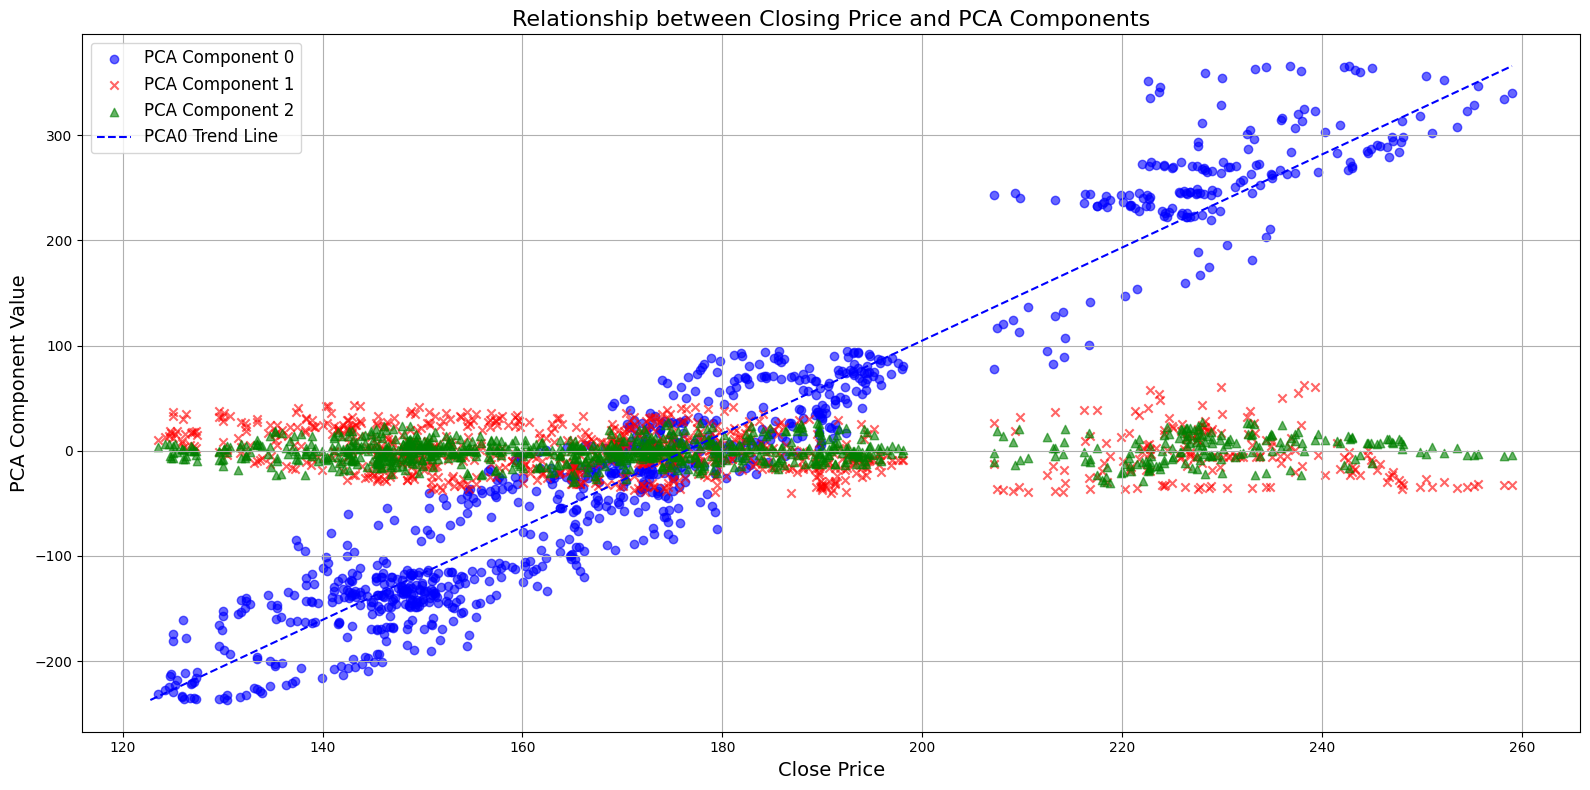

In [98]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8))

# Scatter plots for PCA components
plt.scatter(df['Close'].loc[main_data.index], main_data['pca0'], c='blue', alpha=0.6, label='PCA Component 0', marker='o')
plt.scatter(df['Close'].loc[main_data.index], main_data['pca1'], c='red', alpha=0.6, label='PCA Component 1', marker='x')
plt.scatter(df['Close'].loc[main_data.index], main_data['pca2'], c='green', alpha=0.6, label='PCA Component 2', marker='^')

# Optional: Draw simple line between min and max for pca0 (trend approximation)
x_vals = [df['Close'].min(), df['Close'].max()]
y_vals = [main_data['pca0'].min(), main_data['pca0'].max()]
plt.plot(x_vals, y_vals, color='blue', linestyle='--', label='PCA0 Trend Line')

# Labels and grid
plt.title('Relationship between Closing Price and PCA Components', fontsize=16)
plt.xlabel('Close Price', fontsize=14)
plt.ylabel('PCA Component Value', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()


In [99]:
import tensorflow as tf
from tensorflow import keras
from tensorflow import keras
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [100]:
X=main_data[['pca0']]
y=output.loc[main_data.index]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

In [113]:
# # Define the neural network model
model = keras.Sequential([
    keras.layers.Dense(256, activation='relu', input_shape=(X.shape[1],)),  
    # keras.layers.LSTM(256, return_sequences=True, input_shape=(X.shape[1],)),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(y.shape[1])  # Output layer for regression (no activation)
])
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import LSTM, Dense

# model = Sequential()
# model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
# model.add(LSTM(50, return_sequences=True))
# model.add(LSTM(50))
# model.add(Dense(1))

model.compile(loss='mean_squared_error', metrics=['mae'], optimizer='adam')

# from tensorflow.keras.optimizers import Adam
# model.compile(optimizer=Adam(learning_rate=1e-3), loss='mse', metrics=['mae'])


from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Increase epochs
EPOCHS = 100

# Train the model with callbacks
model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[ checkpoint, early_stop]
)



Epoch 1/100
22/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 162169.9688 - mae: 325.8661
Epoch 1: val_loss improved from inf to 18665.93945, saving model to best_model.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 159939.8750 - mae: 322.5926 - val_loss: 18665.9395 - val_mae: 123.9841
Epoch 2/100
20/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 100771.3672 - mae: 257.7950 
Epoch 2: val_loss did not improve from 18665.93945
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 99799.3672 - mae: 256.0853 - val_loss: 33825.3125 - val_mae: 151.1573
Epoch 3/100
14/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 92483.9375 - mae: 245.1518 
Epoch 3: val_loss did not improve from 18665.93945
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 92285.5156 - mae: 245.4630 - val_loss: 36922.4922 - val_mae: 155.5997
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 92703.6953 - mae: 246.7422
Epoch 4: val_loss did not improve from 18665.93945
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 92699.7031 - m

In [116]:
y_train_pred=model.predict(X_train)
y_test_pred=model.predict(X_test)
y_train = y_train
y_test = y_test

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [117]:
y_train.shape, y_train_pred.shape, y_test.shape, y_test_pred.shape

((764, 3), (764, 1), (191, 1), (191, 1))

In [118]:
y_train.reset_index(inplace=True)

ValueError: cannot insert level_0, already exists

In [119]:
y_train_pred[:,0]

array([ 45.36974   , 369.42072   ,  59.372265  , 392.8967    ,
       123.17677   ,  97.57983   ,  85.56382   , 372.76962   ,
        38.839947  , 482.13696   , 365.1399    ,  79.956154  ,
       466.81427   ,  52.679714  ,  58.867733  , 335.9057    ,
       286.6064    , 239.34999   ,  36.555973  , 363.43103   ,
       244.31331   , 165.36003   , 261.51355   ,  24.320711  ,
       235.02153   , 427.07513   , 247.58534   ,  15.549624  ,
       274.48935   , 129.39815   ,  55.088432  ,  93.08816   ,
       368.7167    ,  38.753853  ,  88.35825   ,   3.1722443 ,
       363.43536   , 330.74445   , 222.61107   , 338.99536   ,
        16.943022  , 143.6858    , 500.64966   ,  39.826477  ,
        12.5363    , 438.44696   , 400.0708    , 396.24402   ,
       321.2548    , 216.07306   , 268.86932   , 435.31393   ,
       100.55424   , 157.08658   , 298.00403   , 218.9605    ,
        30.30752   , 325.06885   ,  65.752075  , 252.31596   ,
        21.64535   , 209.04994   , 175.93001   , 114.99

In [83]:
type(y_train["High"])

pandas.core.series.Series

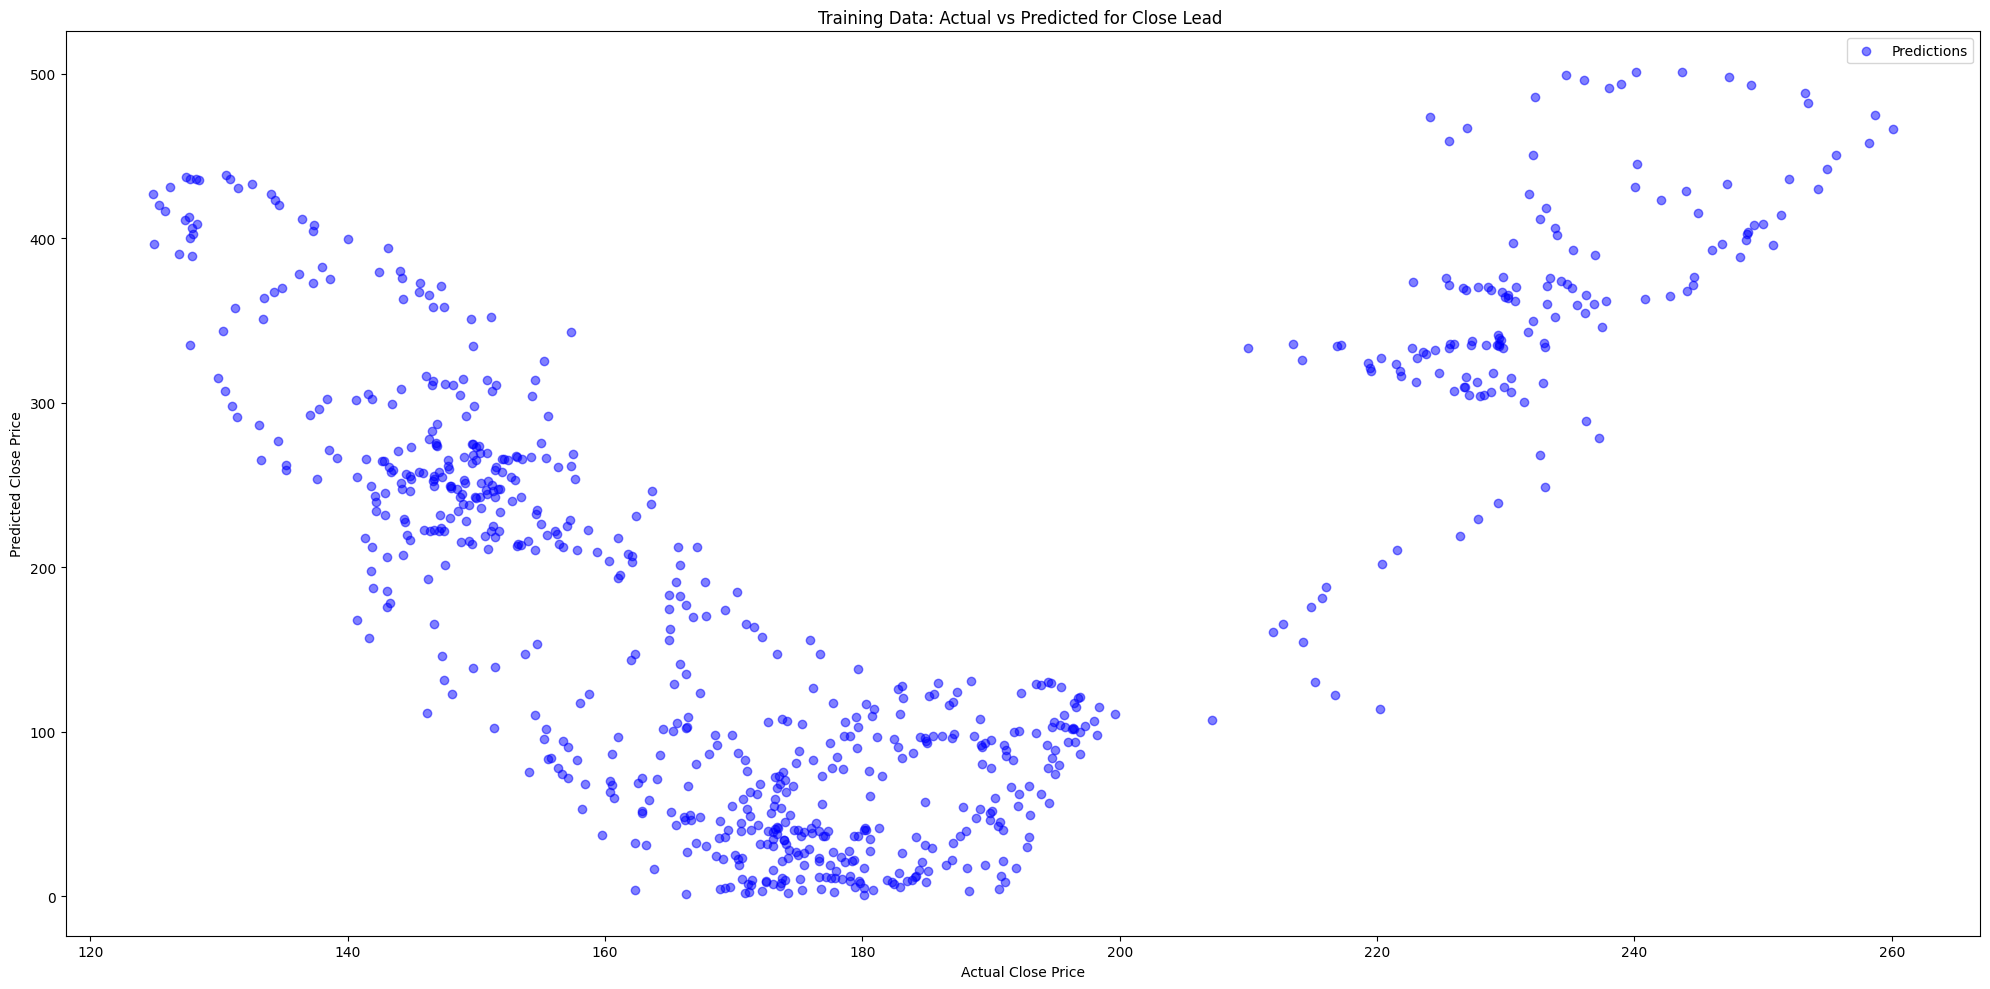

In [120]:
plt.figure(figsize=(20,10))
# for i in range(1,5):
# plt.subplot(2,2,i)
# scalerY.inverse_transform(y_train)
# plt.scatter(scalerY.inverse_transform(y_train), y_train_pred, alpha=0.5, color='blue', label="Predictions")
# plt.plot(scalerY.inverse_transform(y_train), scalerY.inverse_transform(y_train), color='red', linestyle='dashed', label="Ideal Fit")
plt.scatter(y_train['High'].reset_index(drop=True), y_train_pred[:,0], alpha=0.5, color='blue', label="Predictions")
# plt.scatter(y_train['Low'].reset_index(drop=True), y_train_pred[:,1], alpha=0.5, color='red', label="Predictions")
# plt.plot(y_train[:,0], y_train[:,0], color='red', linestyle='dashed', label="Ideal Fit")
plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")
plt.title(f"Training Data: Actual vs Predicted for Close Lead ")
plt.legend()

plt.tight_layout()
plt.show()

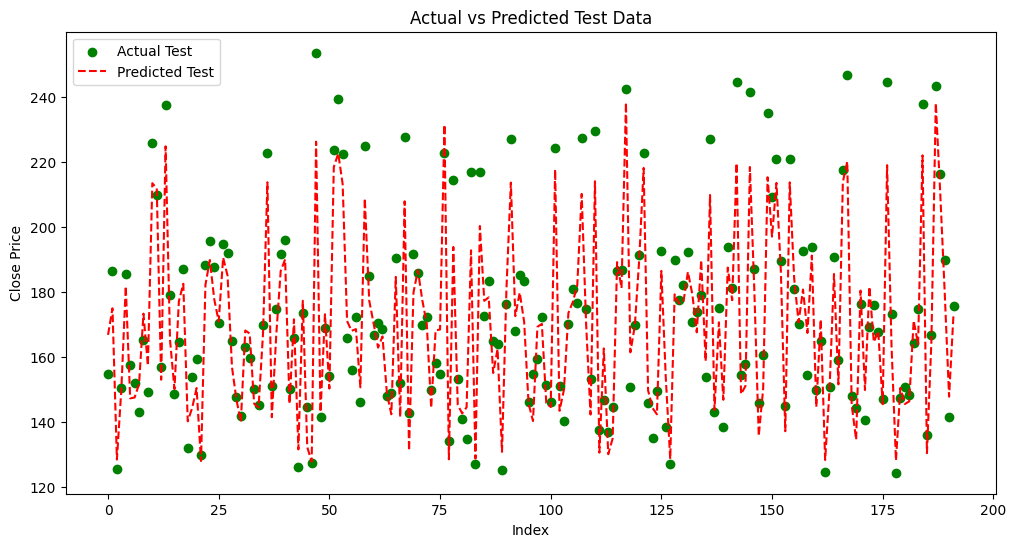

In [18]:
# Plot actual vs predicted values
plt.figure(figsize=(12, 6))
plt.scatter(range(0,  len(y_test)), y_test, label="Actual Test", color='green', linewidth=1)
plt.plot(range(0,  len(y_test)), y_test_pred, label="Predicted Test", color='red', linestyle='dashed')
plt.xlabel("Index")
plt.ylabel("Close Price")
plt.title("Actual vs Predicted Test Data")
plt.legend()
plt.show()

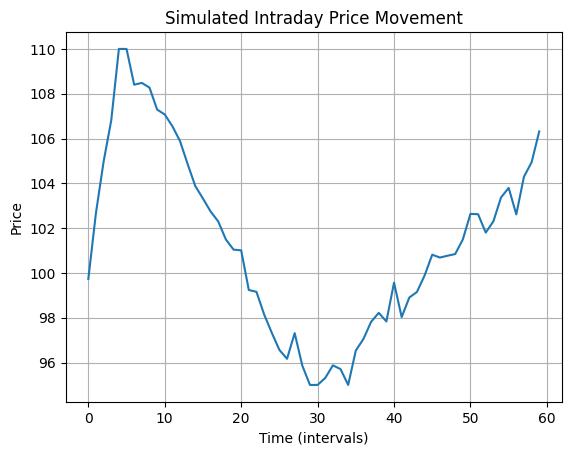

In [76]:
import numpy as np
import matplotlib.pyplot as plt

def generate_intraday_prices(open_price, close_price, high, low, intervals=60, noise_level=0.5):
    if not (low <= min(open_price, close_price) and high >= max(open_price, close_price)):
        raise ValueError("Inconsistent high/low with open/close")

    # Time indices
    t = np.linspace(0, 1, intervals)

    # Random positions for high and low (not at ends)
    high_idx = np.random.randint(0, intervals // 2)
    low_idx = np.random.randint(intervals // 2, intervals * 3 // 4)

    # Three segments
    segment1 = np.linspace(open_price, high, high_idx)
    segment2 = np.linspace(high, low, low_idx - high_idx)
    segment3 = np.linspace(low, close_price, intervals - low_idx)

    # Concatenate
    base_curve = np.concatenate([segment1, segment2, segment3])

    # Add slight noise
    noise = np.random.normal(scale=noise_level, size=intervals)
    price_curve = base_curve + noise

    # Clip to [low, high]
    price_curve = np.clip(price_curve, low, high)

    return price_curve

# Example
open_p, close_p, high_p, low_p = 100, 105, 110, 95
simulated = generate_intraday_prices(open_p, close_p, high_p, low_p)

# Plot
plt.plot(simulated)
plt.title("Simulated Intraday Price Movement")
plt.xlabel("Time (intervals)")
plt.ylabel("Price")
plt.grid(True)
plt.show()


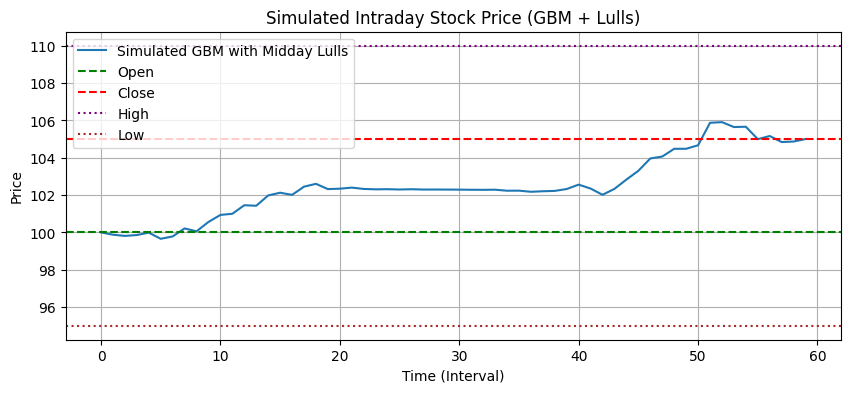

In [16]:
import numpy as np
import matplotlib.pyplot as plt

def generate_gbm_path_with_lulls(open_price, close_price, high, low, intervals=60, mu=0.001, sigma=0.02):
    dt = 1 / intervals
    prices = [open_price]

    # Midday lull: higher volatility at open and close, lower in middle
    time_steps = np.linspace(0, 1, intervals)
    lull_curve = 1 - np.exp(-20 * (time_steps - 0.5) ** 2)  # Bell shape, 0.5 is midday

    for i in range(1, intervals):
        z = np.random.normal()
        effective_sigma = sigma * lull_curve[i]
        prev = prices[-1]
        next_price = prev * np.exp((mu - 0.5 * effective_sigma ** 2) * dt + effective_sigma * np.sqrt(dt) * z)
        prices.append(next_price)

    prices = np.array(prices)

    # Normalize path to start at open and end at close
    prices -= prices[0]
    scale = (close_price - open_price) / (prices[-1] if prices[-1] != 0 else 1)
    prices *= scale
    prices += open_price

    # Clamp to [low, high] range
    prices = np.clip(prices, low, high)

    return prices

# Example usage
open_price, close_price = 100, 105
high, low = 110, 95
gbm_prices = generate_gbm_path_with_lulls(open_price, close_price, high, low)

# Plotting
plt.figure(figsize=(10, 4))
plt.plot(gbm_prices, label="Simulated GBM with Midday Lulls")
plt.axhline(open_price, color='green', linestyle='--', label="Open")
plt.axhline(close_price, color='red', linestyle='--', label="Close")
plt.axhline(high, color='purple', linestyle=':', label="High")
plt.axhline(low, color='brown', linestyle=':', label="Low")
plt.legend()
plt.title("Simulated Intraday Stock Price (GBM + Lulls)")
plt.xlabel("Time (Interval)")
plt.ylabel("Price")
plt.grid(True)
plt.show()


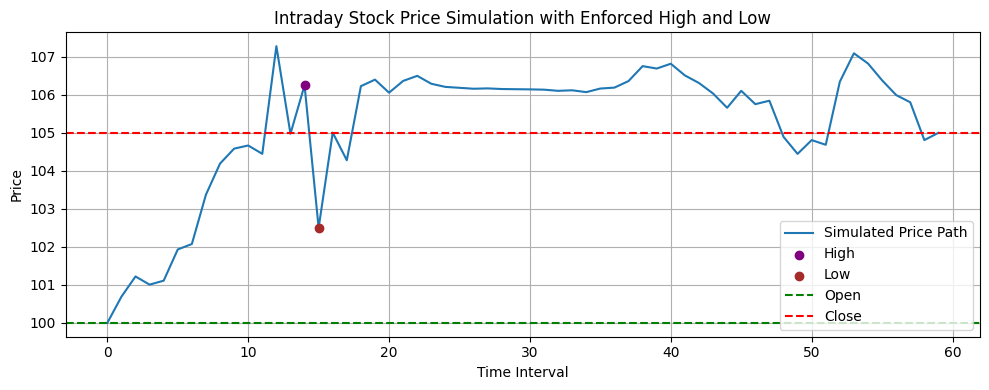

In [45]:
import numpy as np
import matplotlib.pyplot as plt

def generate_intraday_with_high_low(open_price, close_price, high, low, intervals=60, mu=0.001, sigma=0.02):
    dt = 1 / intervals
    prices = [open_price]

    # Midday lull volatility pattern
    time_steps = np.linspace(0, 1, intervals)
    lull_curve = 1 - np.exp(-20 * (time_steps - 0.5) ** 2)

    for i in range(1, intervals):
        z = np.random.normal()
        effective_sigma = sigma * lull_curve[i]
        prev = prices[-1]
        next_price = prev * np.exp((mu - 0.5 * effective_sigma ** 2) * dt + effective_sigma * np.sqrt(dt) * z)
        prices.append(next_price)

    prices = np.array(prices)

    # Normalize path to start at open and end at close
    prices -= prices[0]
    scale = (close_price - open_price) / (prices[-1] if prices[-1] != 0 else 1)
    prices *= scale
    prices += open_price

    # --- Force high and low ---
    valid_indices = np.arange(5, intervals - 5)
    i_high, i_low = np.random.choice(valid_indices, 2, replace=False)
    prices[i_high] = high
    prices[i_low] = low

    # Optional: smooth a bit around forced points (to reduce unnatural spikes)
    def smooth_around(index, window=2):
        for offset in range(-window, window + 1):
            if offset == 0:
                continue
            j = index + offset
            if 0 <= j < intervals:
                prices[j] = (prices[j] + prices[index]) / 2

    smooth_around(i_high)
    smooth_around(i_low)

    # Final clipping just in case
    prices = np.clip(prices, low, high)

    return prices, i_high, i_low

# Example
open_p, close_p, high_p, low_p = 100, 105, 110, 95
path, hi_idx, lo_idx = generate_intraday_with_high_low(open_p, close_p, high_p, low_p)

# Plotting
plt.figure(figsize=(10, 4))
plt.plot(path, label="Simulated Price Path")
plt.scatter([hi_idx], [path[hi_idx]], color='purple', label="High", zorder=5)
plt.scatter([lo_idx], [path[lo_idx]], color='brown', label="Low", zorder=5)
plt.axhline(open_p, color='green', linestyle='--', label="Open")
plt.axhline(close_p, color='red', linestyle='--', label="Close")
plt.legend()
plt.title("Intraday Stock Price Simulation with Enforced High and Low")
plt.xlabel("Time Interval")
plt.ylabel("Price")
plt.grid(True)
plt.tight_layout()
plt.show()


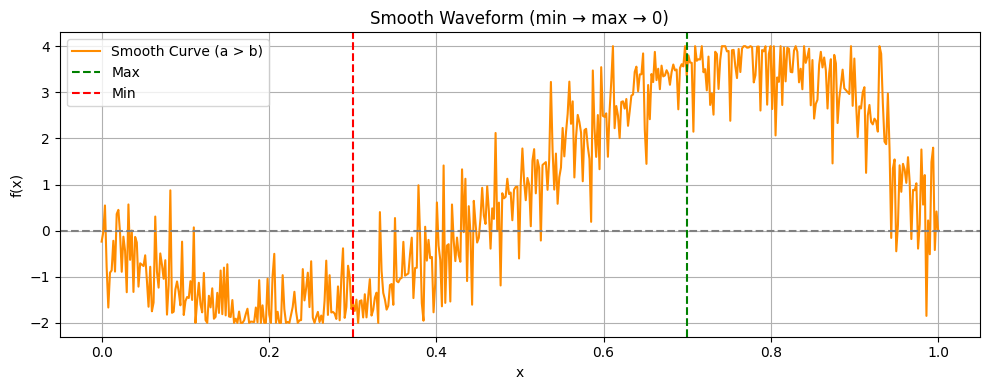

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def get_waveform(x, a=0.3, b=0.7, ma=1.0, mi=-1.0):
    y = np.zeros_like(x)

    if a < b:
        mask1 = x <= a
        # + np.random.normal(0, 0.1, size=np.sum(mask1))
        y[mask1] = ma * np.sin((np.pi * x[mask1]) / (2 * a)) 

        mask2 = (x > a) & (x <= b)
        y[mask2] = ma + (mi - ma) * (1 - np.cos(np.pi * (x[mask2] - a) / (b - a))) / 2 

        mask3 = x > b
        y[mask3] = mi * np.cos((np.pi * (x[mask3] - b)) / (2 * (1 - b))) 

    else:
        mask1 = x <= b
        y[mask1] = mi * np.sin((np.pi * x[mask1]) / (2 * b))

        mask2 = (x > b) & (x <= a)
        y[mask2] = mi + (ma - mi) * (1 - np.cos(np.pi * (x[mask2] - b) / (a - b))) / 2

        mask3 = x > a
        y[mask3] = ma * np.cos((np.pi * (x[mask3] - a)) / (2 * (1 - a)))
    for i in range(len(y)):
        if np.random.rand() < 0.7:  
            y[i] += np.random.normal(0, 0.9)
            if y[i] >= ma:
                y[i] = ma - np.random.normal(0.1, 0.5)
            elif y[i] <= mi:
                y[i] = mi + np.random.normal(0.1, 0.5)
    y = np.clip(y, mi, ma)  
    y = np.where(np.isnan(y), 0, y) 
    return y
# Example usage
x_vals = np.linspace(0, 1, 500)
y_vals = get_waveform(x_vals, a=0.8, b=0.2, ma=4.0, mi=-2.0)

plt.figure(figsize=(10, 4))
plt.plot(x_vals, y_vals, label="Smooth Curve (a > b)", color="darkorange")
plt.axhline(0, color="gray", linestyle="--")
plt.axvline(0.7, color="green", linestyle="--", label="Max")
plt.axvline(0.3, color="red", linestyle="--", label="Min")
plt.title("Smooth Waveform (min → max → 0)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



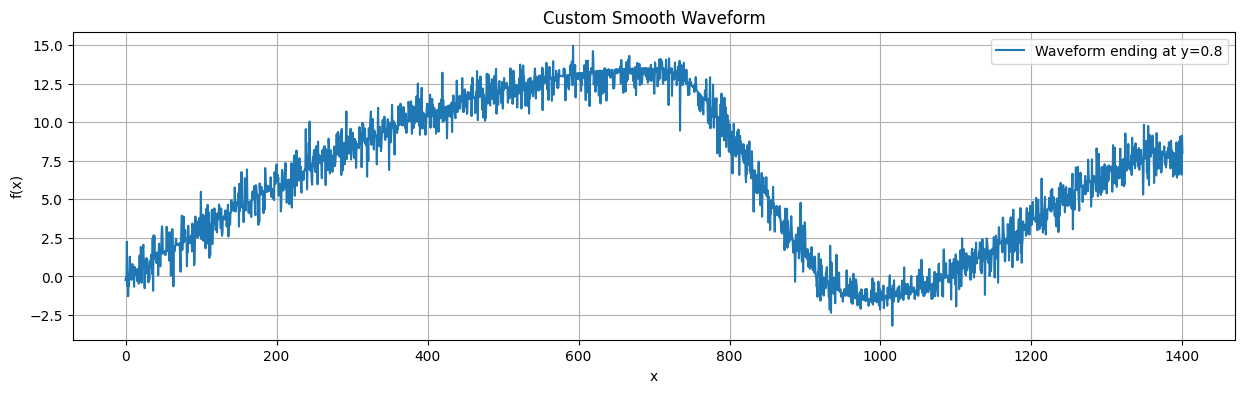

In [17]:
import numpy as np

import numpy as np

def generate_waveform(length, rise_point=0.3, fall_point=0.7, max_amplitude=1.0, min_amplitude=-1.0, final_value=0.5):
    # Create normalized x-axis from 0 to 1
    x_axis = np.linspace(0, 1, length)
    waveform = np.zeros_like(x_axis)

    if rise_point < fall_point:
        # Rising segment
        rise_mask = x_axis <= rise_point
        waveform[rise_mask] = max_amplitude * np.sin((np.pi * x_axis[rise_mask]) / (2 * rise_point))

        # Falling segment
        fall_mask = (x_axis > rise_point) & (x_axis <= fall_point)
        waveform[fall_mask] = max_amplitude + (min_amplitude - max_amplitude) * \
            (1 - np.cos(np.pi * (x_axis[fall_mask] - rise_point) / (fall_point - rise_point))) / 2

        # Tail segment to final value
        tail_mask = x_axis > fall_point
        t = (x_axis[tail_mask] - fall_point) / (1 - fall_point)
        start_tail_value = min_amplitude
        waveform[tail_mask] = start_tail_value + (final_value - start_tail_value) * \
            (1 - np.cos(np.pi * t)) / 2

    else:
        # Rising segment (if fall happens before rise)
        rise_mask = x_axis <= fall_point
        waveform[rise_mask] = min_amplitude * np.sin((np.pi * x_axis[rise_mask]) / (2 * fall_point))

        # Falling segment
        fall_mask = (x_axis > fall_point) & (x_axis <= rise_point)
        waveform[fall_mask] = min_amplitude + (max_amplitude - min_amplitude) * \
            (1 - np.cos(np.pi * (x_axis[fall_mask] - fall_point) / (rise_point - fall_point))) / 2

        # Tail segment to final value
        tail_mask = x_axis > rise_point
        t = (x_axis[tail_mask] - rise_point) / (1 - rise_point)
        start_tail_value = max_amplitude
        waveform[tail_mask] = start_tail_value + (final_value - start_tail_value) * \
            (1 - np.cos(np.pi * t)) / 2

    # Optional: Add noise to simulate realism
    for i in range(length):
        if np.random.rand() < 0.7:
            waveform[i] += np.random.normal(0, 0.9)
        if waveform[i] >= max_amplitude:
            waveform[i] = max_amplitude - np.random.normal(0.1, 0.5)
        elif waveform[i] <= min_amplitude:
            waveform[i] = min_amplitude + np.random.normal(0.1, 0.5)

    waveform = np.nan_to_num(waveform)

    return waveform

import matplotlib.pyplot as plt

length = 2500
y_vals = generate_waveform(length, rise_point=0.5, fall_point=0.7, max_amplitude=13.5, min_amplitude=-1.5, final_value=8)
plt.figure(figsize=(15, 4))
plt.plot(np.linspace(0, 1400, len(y_vals)), y_vals, label="Waveform ending at y=0.8")
plt.title("Custom Smooth Waveform")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.legend()
plt.show()



In [18]:
y_vals.shape

(2500,)

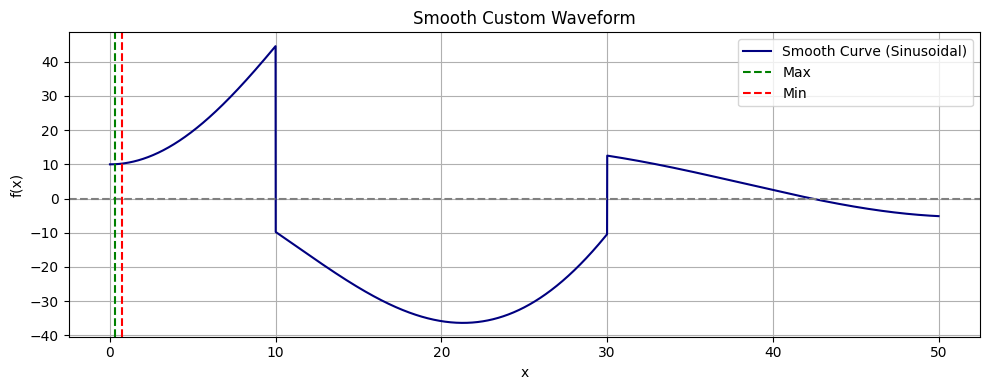

In [89]:
o=10.0
c=30.0
te=50.0
ts=0.0
ma=70.0
x1=10.0
mi=-10.0
x2=30.0
x_vals = np.linspace(ts, te, 5000)
slope = (te - ts) / (( (o - c) ** 2 + (ma - mi) ** 2 ) ** 0.5)
import math
def a(x):
    x = np.asarray(x)
    out = np.zeros_like(x)
    mask1 = (0 < x) & (x < x1)
    mask2 = (x1 < x) & (x < x2)
    mask3 = ~(mask1 | mask2)
    out[mask1] = (ma / x1) * x[mask1]
    out[mask2] = ((mi - ma) / (x2 - x1)) * x[mask2]
    out[mask3] = (-mi / (te - x2)) * x[mask3]
    return out

def b(x):
    return np.pi * x / (x2 - x1)

y_vals = o + slope * (a(x_vals) * np.sin(slope * b(x_vals)))
plt.figure(figsize=(10, 4))
plt.plot(x_vals, y_vals, label="Smooth Curve (Sinusoidal)", color="navy")
plt.axhline(0, color="gray", linestyle="--")
plt.axvline(0.3, color="green", linestyle="--", label="Max")
plt.axvline(0.75, color="red", linestyle="--", label="Min")
plt.title("Smooth Custom Waveform")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [23]:
from dotenv import load_dotenv
load_dotenv(override=True)
from sqlalchemy import create_engine, text
import os
import pandas as pd

engine = create_engine(os.getenv('POSTGRES_URI'))
def sql_execute(query: str):
        """
        Execute a SQL query and return the result as a DataFrame.
        """

        with engine.connect() as connection:
            result = connection.execute(text(query))
            df = pd.DataFrame(result.fetchall(), columns=result.keys())
        return df
latest_unused_data = sql_execute(query=f"SELECT * FROM AAPL WHERE used = False ORDER BY index ASC LIMIT 1")

In [24]:
latest_unused_data

,level_0,open,high,low,close,volume,index,used,open_Trend,open_Seasonal,...,high_Bollinger_Lower,low_EMA,low_Bollinger_Upper,low_Bollinger_Lower,close_EMA,close_Bollinger_Upper,close_Bollinger_Lower,volume_EMA,volume_Bollinger_Upper,volume_Bollinger_Lower
0,999,136.17,137.41,135.87,136.96,63261393,2021-06-30,False,None,-0.075204,...,None,135.87,None,None,136.96,None,None,63261393.0,None,None


In [30]:
y_vals=generate_waveform(
    length=500,
    rise_point=0.5,
    fall_point=0.7,
    max_amplitude=latest_unused_data['high'].values[0],
    min_amplitude=latest_unused_data['low'].values[0],
    final_value=latest_unused_data['close'].values[0]
)

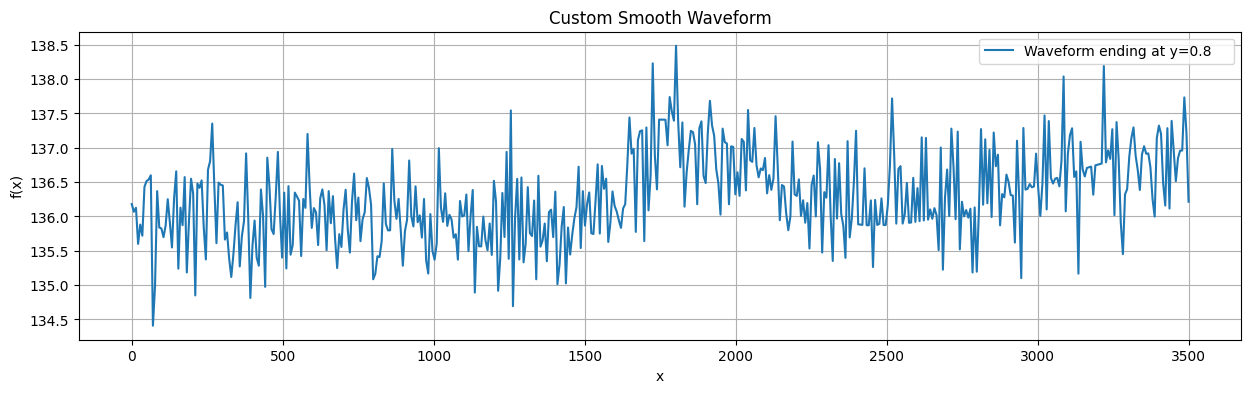

In [32]:
x_vals=np.linspace(0, 3500, len(y_vals))
plt.figure(figsize=(15, 4))
plt.plot(x_vals, y_vals, label="Waveform ending at y=0.8    ")
plt.title("Custom Smooth Waveform")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.legend()
plt.show()